In [33]:
import numpy as np
from scipy.optimize import fsolve
from scipy.integrate import solve_ivp
import sys
from pathlib import Path
import importlib
# add Modeling/ to Python path
project_root = Path.cwd().parents[2]
sys.path.append(str(project_root))
import Modeling
importlib.reload(Modeling)
from Modeling.models.plotting import animate_field_1d
from Modeling.models.beam_properties import PiezoBeamParams


from Modeling.models import FE_helpers 
importlib.reload(FE_helpers)
import matplotlib.pyplot as plt
# from Modeling.models.ROM import ROM

import Modeling.models.FE3 as FE_module
importlib.reload(FE_module)
FE = FE_module


# Piezo-Beam FE Analysis with Arbitrary Region Types

## Simplified Geometry Definition

This notebook demonstrates a flexible approach to defining beam geometries with arbitrary material regions.

### Key Features:
1. **Define region types once** in a dictionary (substrate, piezo, Kapton, etc.)
2. **Specify layout** as a simple sequence: `['substrate', 'Kapton',  'piezo', 'Kapton', 'substrate', ...]`
3. **Set start positions** for each region: `[0, 5e-3, 30e-3, ...]`
   - Each region automatically ends where the next begins
   - Last region extends to beam length L
4. **Auto-detect piezos**: Any region type with "piezo" in its name is automatically treated as a piezo actuator/shunted

### Interface:
```python
region_types = {
    'substrate': {'EI': 1e-3, 'rhoA': 0.01, 'h': 5e-3},
    'piezo': {'EI': 5e-3, 'rhoA': 0.05, 'h': 2e-3},
    'mass': {'EI': 2e-2, 'rhoA': 0.5, 'h': 1e-3}
}

geom = build_geometry_from_types(
    L=0.4,
    region_types=region_types,
    region_sequence=['substrate', 'piezo', 'substrate', 'mass', 'piezo', 'substrate'],
    x_starts=[0, 0.05, 0.08, 0.15, 0.20, 0.23]
)
# Piezos at indices 1 and 4 are automatically detected by name
```


In [34]:

def compute_EI_and_rhoA(
	E_layers: np.ndarray,
	rho_layers: np.ndarray,
	h_layers: np.ndarray,
	b_layers: np.ndarray,
):
	"""
	Compute bending stiffness EI and mass per unit length mu
	for a symmetric layered beam.

	Layer ordering:
	- First layer is the mid-layer
	- Subsequent layers are stacked outward symmetrically

	Allows:
	- Different width for each layer
	"""

	E_layers = np.asarray(E_layers, dtype=float)
	rho_layers = np.asarray(rho_layers, dtype=float)
	h_layers = np.asarray(h_layers, dtype=float)
	b_layers = np.asarray(b_layers, dtype=float)

	assert len(E_layers) == len(h_layers) == len(rho_layers) == len(b_layers)
	y = [h_layers[0]/2]
	for i in range(1, len(h_layers)):
		y.append(y[i-1] + h_layers[i])
	EI = 0.0
	rhoA = 0.0
	for i, (E, b) in enumerate(zip(E_layers, b_layers)):
		if i==0:
			EI += E * b * y[i]**3 / 3 
			rhoA += rho_layers[i] * b * h_layers[i]/2
		else:
			EI += E * b * ( y[i] ** 3 - y[i-1] ** 3 )/3
			rhoA += rho_layers[i] * b * h_layers[i]

	assert len(y) == len(E_layers) == len(h_layers) == len(rho_layers) == len(b_layers)
	return 2*EI, 2*rhoA


In [35]:
# ============================================================
# Beam parameters 
# Here is wehre you can control strucural damping, and piezo properties
# ============================================================
params_fe = PiezoBeamParams(
    d31=-1.48e-10,        # Piezoelectric strain coefficient [m/V]
    eps_r=1700,           # Relative permittivity (dielectric constant)
    omega_p=2*np.pi*1,    # Lower frequency for Rayleigh damping [rad/s] (1 Hz)
    omega_q=2*np.pi*100   # Upper frequency for Rayleigh damping [rad/s] (100 Hz)
)
# Damping ratios at reference frequencies
params_fe.zeta_p = 0.05   # Modal damping ratio at omega_p (~5%)
params_fe.zeta_q = 0.2    # Modal damping ratio at omega_q (~20%)


# Material properties for different region types
L = 0.3             # beam length [m]
b_s = 50e-3          # substrate width [m]
b_p = 14e-3          # piezo width [m]
b_k = 25e-3          # kapton width [m]
h_s = 0.5e-3        # Substrate thickness [m]
h_p = 0.12e-3        # Piezo layer thickness [m]
h_k = 0.2e-3        # Kapton layer thickness [m] (for mass region)
rho_s = 1190       # Substrate density [kg/m³]
rho_p = 7800       # Piezo density [kg/m³]
rho_k = 1420       # Kapton density [kg/m³] (for mass region)
E_s = 3e9          # Substrate Young's modulus [Pa]
E_p = 31e9         # Piezo Young's modulus [Pa]
E_k = 3e9         # Kapton Young's modulus [Pa] (for mass region)
EI_kapton, rhoA_kapton = compute_EI_and_rhoA(E_layers=[E_s, E_k], rho_layers=[rho_s, rho_k], h_layers=[h_s, h_k], b_layers=[b_s, b_k])
EI_piezo, rhoA_piezo = compute_EI_and_rhoA(E_layers=[E_s, E_k, E_p], rho_layers=[rho_s, rho_k, rho_p], h_layers=[h_s, h_k, h_p], b_layers=[b_s, b_k, b_p])
print(f"Piezo: EI={EI_piezo:.2e} Nm², rhoA={rhoA_piezo:.2f} kg/m")
# Calculate properties for substrate (gap) regions
rhoA_substrate = b_s * rho_s * h_s
EI_substrate = b_s * E_s * h_s**3 / 12

print(f"Substrate: EI={EI_substrate:.2e} Nm², rhoA={rhoA_substrate:.2f} kg/m")
print(f"Piezo: EI={EI_piezo:.2e} Nm², rhoA={rhoA_piezo:.2f} kg/m")
print(f"Kapton (mass): EI={EI_kapton:.2e} Nm², rhoA={b_k * rho_k * h_k:.2f} kg/m")


Piezo: EI=3.26e-02 Nm², rhoA=0.07 kg/m
Substrate: EI=1.56e-03 Nm², rhoA=0.03 kg/m
Piezo: EI=3.26e-02 Nm², rhoA=0.07 kg/m
Kapton (mass): EI=5.34e-03 Nm², rhoA=0.01 kg/m


In [36]:

region_types = {
    'substrate': {'EI': EI_substrate, 'rhoA': rhoA_substrate},
    'piezo': {'EI': EI_piezo, 'rhoA': rhoA_piezo},
    'kapton': {'EI': EI_kapton, 'rhoA': rhoA_kapton}
}
region_sequence = ['substrate',
                   'kapton', 'piezo', 'kapton', 'substrate',
                   'kapton', 'piezo', 'kapton', 'substrate',
                   'kapton', 'piezo', 'kapton', 'substrate',
                   'kapton', 'piezo', 'kapton', 'substrate',
                   'kapton', 'piezo', 'kapton', 'substrate']
x_starts = np.array([0,
                      5, 9.5, 37.5, 42,
                      45, 49.5, 77.5, 82,
                      85, 89.5, 117.5, 122,
                      125, 129.5, 157.5, 162,
                      165, 169.5, 197.5, 202]) * 1e-3
                    

geom = FE_module.build_geometry_from_types(L, region_types, region_sequence, x_starts)
# Automatically detects piezos at indices 1 and 4

params_fe.geometry = geom

# ============================================================
# Build finite element model
# ============================================================
fe = FE_module.PiezoBeamFE(params_fe)

# ============================================================
# Multi-piezo excitation setup with phase control
# ============================================================
j_exc = [0]  # Indices of excited (actuator) piezos

# Time-domain simulation parameters
t_end = 10         # Simulation duration [s]
f0 = 0.1           # Starting frequency for chirp [Hz]
f1 = 100           # Ending frequency for chirp [Hz]
dt = 1/f1/20       # Time step (20 samples per highest frequency period) [s]

# Excitation amplitudes for each piezo [V]
A1, A2, A3 = 1, 15, 20

# Phase offsets for each piezo [rad]
phase1, phase2, phase3 = 0, np.pi/4, np.pi/2  # 0°, 45°, 90°

def v_exc(t):
    """
    Multi-piezo chirp excitation with phase offsets.
    Each piezo gets a frequency sweep with different amplitude and phase.
    
    Returns:
        array: Voltage for each excited piezo at time t
    """
    v0 = A1 * np.sin(2*np.pi*(f0 + t*(f1-f0)/t_end) * t + phase1)
    v1 = A2 * np.sin(2*np.pi*(f0 + t*(f1-f0)/t_end) * t + phase2)
    v2 = A3 * np.sin(2*np.pi*(f0 + t*(f1-f0)/t_end) * t + phase3)
    return np.array([v0])  # Single piezo excitation
    # return np.array([v0, v1, v2])  # Triple piezo excitation (uncomment for multi-piezo)

# Complex weights for frequency-domain analysis (amplitude * exp(i*phase))
phase_exc = np.array([phase1, phase2, phase3])
A_exc = np.array([A1, A2, A3])
weights_complex = A_exc * np.exp(1j * phase_exc)

# ============================================================
# Build ODE system with multi-piezo excitation
# ============================================================
ode = fe.build_ode_system(
    j_exc=j_exc,                           # Excited piezo indices
    R_c=1e3,                               # Circuit resistance [Ω]
    K_p=0.02,                              # Proportional feedback gain
    K_i=0.001,                             # Integral feedback gain
    K_c=0.0,                               # Cubic nonlinear gain (disabled)
    v_exc=v_exc                            # Time-domain excitation function
)

# ============================================================
# Frequency-domain FRF sweep
# ============================================================
f_fe = np.linspace(f0, f1, 500)                     # Frequency vector [Hz]
frf_fd = FE_helpers.frf_sweep(ode, f_fe*2*np.pi)   # Sweep (convert to rad/s)

# Extract frequency-domain results
N = ode.N_mech                                      # Number of mechanical DOFs
w_fd = frf_fd['u']                                  # Displacement FRF (complex)
w_dot_fd = frf_fd['u_dot']                          # Velocity FRF (complex)
freq_fd = frf_fd['freq']                            # Frequency vector [Hz]
vel_fd = np.mean(np.abs(w_dot_fd), axis=1)         # Spatially-averaged velocity magnitude

# ============================================================
# Time-domain simulation (Newmark-beta integration)
# ============================================================
# Initial conditions
ndof = ode.M.shape[0]                               # Total DOFs (mech + elec)
x0 = np.zeros(ndof)                                 # Zero initial displacement/charge
x_dot0 = np.zeros(ndof)                             # Zero initial velocity/voltage

# Run time integration
result = FE_helpers.solve_newmark(
	ode=ode,
	dt=dt,                                          # Time step [s]
	t_end=t_end,                                    # End time [s]
	beta=0.25,                                      # Newmark parameter (average acceleration)
	gamma=0.5,                                      # Newmark parameter (trapezoidal rule)
	newton_tol=1e-8,                                # Newton-Raphson convergence tolerance
	newton_maxiter=8,                               # Max Newton iterations per step
	x0=x0,
	x_dot0=x_dot0
)

# ============================================================
# Extract time-domain results
# ============================================================
t = result['t']                  # Time vector [s]
w = result['u']                  # Mechanical displacement [m]
w_dot = result['u_dot']          # Mechanical velocity [m/s]
w_ddot = result['u_ddot']        # Mechanical acceleration [m/s²]
q = result['q']                  # Electrical charge [C]
v = result['v']                  # Voltage [V]
spec_td = result['spectral']     # Time-domain FRF (FFT-based)


FRF sweep:   0%|          | 0/500 [00:00<?, ?it/s]

Newmark Integration: 100%|██████████| 20000/20000 [03:18<00:00, 100.73step/s]


X shape: (20001,) Y shape: (20001, 309) freq shape: (20001,) veloc shape: (20001, 309)


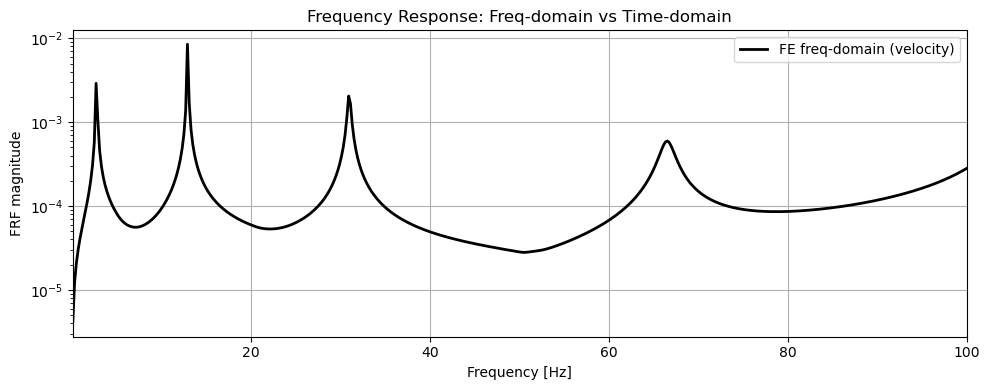

In [37]:

# Time-domain FRF from FFT
# freq_td = spec_td['freq']        # Frequency vector from FFT [Hz]
# frf_td = spec_td['FRF']          # FRF magnitude (spatially averaged)

# ============================================================
# Plot FRF comparison (frequency vs time domain)
# ============================================================
plt.figure(figsize=(10, 4))
# frf_td_y = np.mean(np.abs(spec_td['Y']), axis=1)

plt.semilogy(freq_fd, vel_fd/1.2, 'k-', lw=2, label='FE freq-domain (velocity)')
# plt.semilogy(freq_td, frf_td_y/1.5, '.-', label='FE time-domain (velocity)')
plt.xlabel('Frequency [Hz]')
plt.ylabel('FRF magnitude')
plt.xlim([f0, f1])
plt.grid(True)
plt.legend()
plt.title('Frequency Response: Freq-domain vs Time-domain')
plt.tight_layout()
plt.show()

In [38]:
v_exc(t).shape

(1, 20001)

Saving frame 500/500Saved animation to ./anim/test.mp4


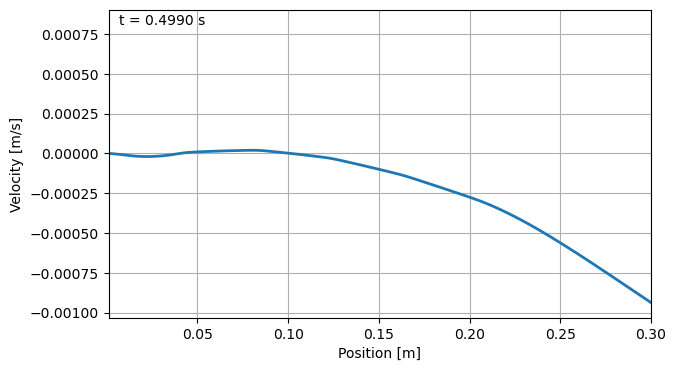

In [39]:
# After creating envelope_func and loading FE results
from Modeling.models import plotting
importlib.reload(plotting)

temporal_slice = slice(0,1000 )
plotting.animate_field_1d(
    t=t[temporal_slice],
    u=w_dot[temporal_slice],  # or w for displacement
    x=fe.geom.x_nodes[1:],  # spatial grid
    filename=f"./anim/test.mp4",
    scale=1.0,
    stride=2,
    ylabel="Velocity [m/s]",
    xlabel="Position [m]",
    fps=50,
    # y_lim_scale=0.8
)

In [40]:
# ============================================================
# Example: Simplified geometry definition with region types
# Using build_geometry_from_types for easy beam design
# ============================================================

# ============================================================
# Step 1: Define all region types (material properties)
# ============================================================
region_types = {
    # Flexible substrate
    'substrate': {
        'EI': 1e-4,
        'rhoA': 0.01,
        'h': 5e-3       # coarse mesh
    },
    
    # Piezo patches (composite)
    'piezo': {
        'EI': 5e-3,
        'rhoA': 0.05,
        'h': 2e-3       # fine mesh
    },
    
    # Heavy concentrated mass
    'mass': {
        'EI': 2e-2,
        'rhoA': 0.5,    # 50x heavier than substrate
        'h': 1e-3       # very fine mesh
    },
    
    # Stiff section (reinforcement)
    'stiff': {
        'EI': 1e-1,
        'rhoA': 0.1,
        'h': 3e-3
    }
}

# ============================================================
# Step 2: Define beam layout
# ============================================================
# Sequence: what type of region comes in order
region_sequence = [
    'substrate',  # 0: start
    'piezo',      # 1: piezo patch 1
    'substrate',  # 2: gap
    'mass',       # 3: heavy mass block
    'stiff',      # 4: stiffened section
    'piezo',      # 5: piezo patch 2
    'substrate'   # 6: end
]

# Start positions: where each region begins [m]
# (Each region automatically ends where the next one starts)
x_starts = [
    0.0,       # substrate starts at 0
    50e-3,     # piezo 1 starts at 50mm
    80e-3,     # substrate gap starts at 80mm
    150e-3,    # mass block starts at 150mm
    160e-3,    # stiff section starts at 160mm
    200e-3,    # piezo 2 starts at 200mm
    230e-3     # substrate continues to end (400mm)
]

# Piezo indices: which regions are piezos (0-indexed)
piezo_regions = [1, 5]  # regions 1 and 5 are piezo patches

# ============================================================
# Step 3: Build geometry with one function call
# ============================================================
geom_custom = FE_module.build_geometry_from_types(
    L=400e-3,                       # Total beam length
    region_types=region_types,      # Type definitions
    region_sequence=region_sequence, # Layout order
    x_starts=x_starts,              # Start positions
    piezo_regions=piezo_regions,    # Piezo indices
    default_h=5e-3
)

print(f"Custom geometry created:")
print(f"  Total nodes: {len(geom_custom.x_nodes)}")
print(f"  Total elements: {len(geom_custom.elem_EI)}")
print(f"  Piezos: {len(geom_custom.piezos)}")
print(f"\nRegion layout:")
for i, (rtype, x_start) in enumerate(zip(region_sequence, x_starts)):
    x_end = x_starts[i+1] if i < len(x_starts)-1 else 400e-3
    piezo_marker = " [PIEZO]" if i in piezo_regions else ""
    print(f"  {i}: {rtype:12s}  {x_start*1e3:6.1f} - {x_end*1e3:6.1f} mm{piezo_marker}")

# ============================================================
# Use custom geometry in FE model
# ============================================================
params_fe_custom = PiezoBeamParams(
    d31=-1.48e-10,
    eps_r=1700,
    omega_p=2*np.pi*1,
    omega_q=2*np.pi*100
)
params_fe_custom.zeta_p = 0.02
params_fe_custom.zeta_q = 0.05
params_fe_custom.geometry = geom_custom

fe_custom = FE_module.PiezoBeamFE(params_fe_custom)

# Run eigenanalysis to see modes
freq_custom, omega_custom, Phi_custom = fe_custom.eigen_analysis()
print(f"\nFirst 10 natural frequencies [Hz]:")
print(freq_custom[:10])

# ============================================================
# Plot mode shapes with region highlighting
# ============================================================
fig, axes = plt.subplots(3, 1, figsize=(12, 8))
x_plot = geom_custom.x_nodes * 1e3  # convert to mm

for i, ax in enumerate(axes):
    mode_idx = i
    ax.plot(x_plot, Phi_custom[::2, mode_idx], 'b-', lw=2, label=f'Mode {mode_idx+1}')
    
    # Highlight different regions with background colors
    for j, (rtype, x_start) in enumerate(zip(region_sequence, x_starts)):
        x_end = x_starts[j+1]*1e3 if j < len(x_starts)-1 else 400
        x_start_mm = x_start * 1e3
        
        if rtype == 'piezo':
            ax.axvspan(x_start_mm, x_end, alpha=0.2, color='red', 
                      label='Piezo' if i==0 and j==1 else '')
        elif rtype == 'mass':
            ax.axvspan(x_start_mm, x_end, alpha=0.3, color='gray', 
                      label='Mass' if i==0 else '')
        elif rtype == 'stiff':
            ax.axvspan(x_start_mm, x_end, alpha=0.2, color='green', 
                      label='Stiff' if i==0 else '')
    
    ax.set_ylabel('Amplitude')
    ax.set_title(f'Mode {mode_idx+1}: {freq_custom[mode_idx]:.2f} Hz')
    ax.grid(True, alpha=0.3)
    if i == 0:
        ax.legend(loc='upper right')
    if i == len(axes)-1:
        ax.set_xlabel('Position [mm]')

plt.tight_layout()
plt.show()

TypeError: build_geometry_from_types() got an unexpected keyword argument 'piezo_regions'